In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import requests
import itertools
from scipy.interpolate import Rbf
import geopandas as gpd
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

## 1.1. Helper Functions

In [2]:
def rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    return float(np.sqrt(np.mean((a - b) ** 2)))

def corr(a, b):
    aa = np.asarray(a, float).ravel()
    bb = np.asarray(b, float).ravel()
    
    if np.std(aa) < 1e-12 or np.std(bb) < 1e-12:
        return float("nan")
        
    return float(np.corrcoef(aa, bb)[0, 1])

## 1.2. Load NYT Data
The New York Times (Covid-19) Cases and Deaths in the United States (https://www.nytimes.com/interactive/2020/us/about-coronavirus-data-maps.html)

In [3]:
STATE = "Texas" 
DATES = ["2020-07-01", "2021-09-01", "2022-01-01", "2022-05-13" ]

nyt = pd.read_csv("geo_data/us_counties_nyt.csv", dtype={"fips": "string"})
nyt["date"] = pd.to_datetime(nyt["date"])
nyt = nyt.dropna(subset=["fips"])
nyt["fips"] = nyt["fips"].astype(str).str.zfill(5)  # ensure 5-digit county code

print(f"Loaded {len(nyt):,} rows total")
print(f"Date range: {nyt['date'].min().date()} → {nyt['date'].max().date()}")

region_nyt = nyt[nyt["state"] == STATE].copy()
print(f"\n{STATE} state rows: {len(region_nyt):,}")
print(f"Counties found: {region_nyt['county'].nunique()}")
print(f"\nSample of {STATE} data:")
print(region_nyt[region_nyt["date"] == "2021-01-01"][["date","county","fips","cases"]].sample(8).to_string(index=False))
# print(region_nyt)

Loaded 2,479,154 rows total
Date range: 2020-01-21 → 2022-05-13

Texas state rows: 193,498
Counties found: 255

Sample of Texas data:
      date        county  fips  cases
2021-01-01     Jim Wells 48249   2850
2021-01-01          Hale 48189   5152
2021-01-01        Burnet 48053   1964
2021-01-01        Parker 48367   8790
2021-01-01         Titus 48449   2544
2021-01-01 Collingsworth 48087    211
2021-01-01         Falls 48145   1199
2021-01-01     Armstrong 48011    110


Date range : 2020-02-12 → 2022-05-13
Texas rows : 193,498
Counties   : 255
Top 10 counties: ['Harris', 'Dallas', 'Tarrant', 'Bexar', 'Travis', 'Collin', 'El Paso', 'Hidalgo', 'Fort Bend', 'Denton']


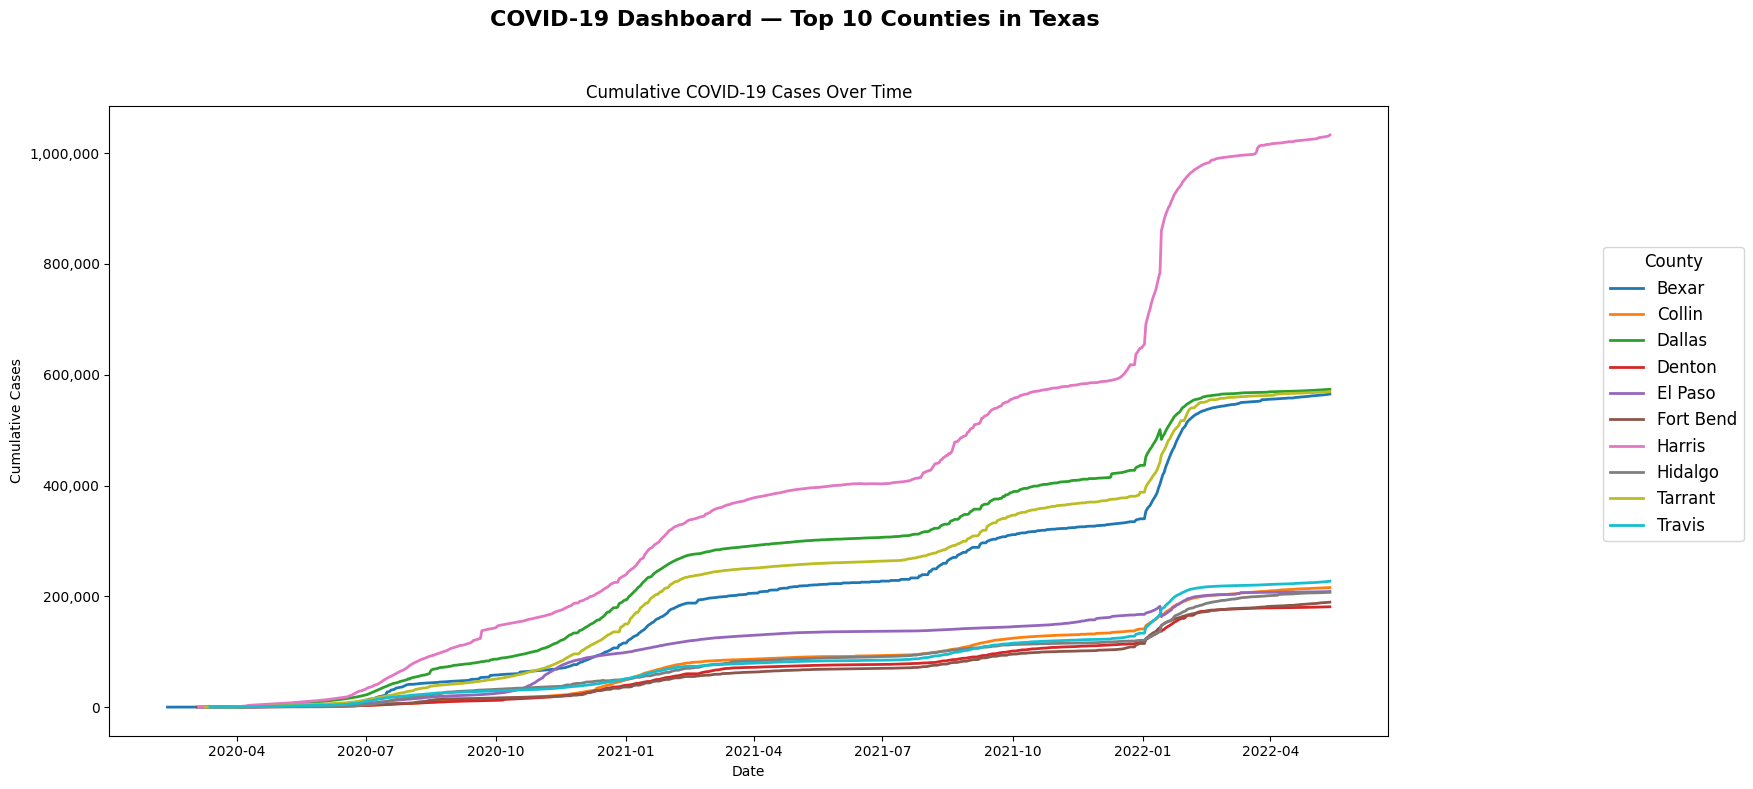

In [4]:
region_sorted = nyt[nyt["state"] == STATE].copy()
region_sorted = region_sorted.sort_values(["county", "date"])

print(f"Date range : {region_sorted['date'].min().date()} → {region_sorted['date'].max().date()}")
print(f"{STATE} rows : {len(region_sorted):,}")
print(f"Counties   : {region_sorted['county'].nunique()}")

top_counties = region_sorted.groupby("county")["cases"].max().nlargest(10).index
print(f"Top 10 counties: {list(top_counties)}")

df_top = region_sorted[region_sorted["county"].isin(top_counties)].copy()

pivot_cumulative = (
    df_top.pivot(index="date", columns="county", values="cases")
          .sort_index()
)

fig, ax1 = plt.subplots(figsize=(16, 8))
fig.suptitle(
    f"COVID-19 Dashboard — Top 10 Counties in {STATE}",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

# Plot — Cumulative cases
for county in pivot_cumulative.columns:
    ax1.plot(pivot_cumulative.index, pivot_cumulative[county], linewidth=2, label=county)

ax1.set_ylabel("Cumulative Cases")
ax1.set_xlabel("Date")
ax1.set_title("Cumulative COVID-19 Cases Over Time")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="County",
    bbox_to_anchor=(1, 0.5),
    loc="center left",
    fontsize=12,
    title_fontsize=12,
)

plt.tight_layout(rect=[0, 0, 0.88, 0.95])
plt.show()

## 1.3. Load Census Boundaries & Centroid Extraction

Each county is represented by a polygon $P_i \subset \mathbb{R}^2$ obtained from the county boundary dataset. To assign a spatial location to each county, we compute the **centroid** of the polygon:

$$ (x_i,y_i)=\left(\frac{1}{|P_i|}\int_{P_i}x\,dA,\; 
\frac{1}{|P_i|}\int_{P_i}y\,dA\right)$$

where $P_i$ is the area of the county.

The centroid is first computed in a projected coordinate system ($EPSG:3857$) for geometric accuracy, then converted back to geographic coordinates ($EPSG:4326$) to obtain the county **longitude** and **latitude**: $ (\text{clon}_i,\ \text{clat}_i) $

In [5]:
kml_path = "/Users/atalha/Desktop/Neumann_ADI/Neumann/geo_data/cb_2023_us_county_500k.kml"
counties = gpd.read_file(kml_path).to_crs(epsg=4326)
counties["GEOID"] = counties["GEOID"].astype(str).str.zfill(5)

region_count = counties[counties["GEOID"].isin(set(region_nyt["fips"].unique()))].copy()
print(f"{STATE} counties matched to map shapes: {len(region_count)}")

rc_proj = region_count.to_crs(epsg=3857)
cent = rc_proj.geometry.centroid
cent_wgs = gpd.GeoSeries(cent, crs=3857).to_crs(epsg=4326)
region_count["clon"] = cent_wgs.x
region_count["clat"] = cent_wgs.y
print(f"\nSample county centroids:\n")
print(region_count[["GEOID","Name","clon","clat"]].sample(6).to_string(index=False))

Texas counties matched to map shapes: 254

Sample county centroids:

GEOID      Name        clon      clat
48105  Crockett -101.412251 30.723951
48201    Harris  -95.393904 29.858163
48381   Randall -101.897036 34.966167
48479      Webb  -99.331898 27.761990
48451 Tom Green -100.462250 31.404908
48247  Jim Hogg  -98.697341 27.043745


In [6]:
def date_range_from_dates(dates):
    d0 = pd.to_datetime(min(dates))
    d1 = pd.to_datetime(max(dates))
    return pd.date_range(d0, d1, freq="D")

all_days = date_range_from_dates(DATES)
print(f"Days to process: {len(all_days)} ({all_days[0].date()} → {all_days[-1].date()})")

region_nyt = region_nyt.sort_values(["fips", "date"])
region_nyt["cases"] = region_nyt["cases"].fillna(0.0)

print(f"\nSample showing cumulative vs daily_new for Dallas County:")
king = region_nyt[region_nyt["county"] == "Dallas"][["date","cases"]]
king = king[(king["date"] >= "2021-03-27") & (king["date"] <= "2021-04-10")]
print(king.to_string(index=False))

Days to process: 682 (2020-07-01 → 2022-05-13)

Sample showing cumulative vs daily_new for Dallas County:
      date  cases
2021-03-27 290108
2021-03-28 290108
2021-03-29 290617
2021-03-30 290898
2021-03-31 291262
2021-04-01 291589
2021-04-02 291859
2021-04-03 292153
2021-04-04 292153
2021-04-05 292364
2021-04-06 292743
2021-04-07 293121
2021-04-08 293150
2021-04-09 293659
2021-04-10 293934


## 1.4. Computational Grid Construction

Let the region bounding box be
$
[\lambda_{\min},\lambda_{\max}] \times [\phi_{\min},\phi_{\max}],
$
with padding $\delta$ added to each boundary.

A uniform grid with $N_x \times N_y$ points is generated using

$$
\lambda_j = \lambda_{\min} + j\frac{\lambda_{\max}-\lambda_{\min}}{N_x-1}, 
\quad j=0,\dots,N_x-1
$$

$$
\phi_k = \phi_{\min} + k\frac{\phi_{\max}-\phi_{\min}}{N_y-1}, 
\quad k=0,\dots,N_y-1
$$

The computational mesh is $(\text{Lon},\text{Lat}) = \{(\lambda_j,\phi_k)\}$


## 2.1. Scattered County Data to Continuous Surface

## RBF Interpolation

**Goal:** Find weights $w_i$ such that the interpolant exactly passes through all data points.

The interpolant is:

$$\hat{f}(\mathbf{x}) = \sum_{i=1}^{N} w_i \, \phi\left(\|\mathbf{x} - \mathbf{x}_i\|\right)$$

With the **Gaussian kernel**:

$$\phi(r) = \exp\left(-(\varepsilon r)^2\right)$$

where $r = \|\mathbf{x} - \mathbf{x}_i\|$ is the Euclidean distance and $\varepsilon$ is the fixed shape parameter.

**Solving for weights** requires building the system:

$$\underbrace{\begin{bmatrix} \phi(r_{11}) & \cdots & \phi(r_{1N}) \\ \vdots & \ddots & \vdots \\ \phi(r_{N1}) & \cdots & \phi(r_{NN}) \end{bmatrix}}_{\Phi} \begin{bmatrix} w_1 \\ \vdots \\ w_N \end{bmatrix} = \begin{bmatrix} y_1 \\ \vdots \\ y_N \end{bmatrix}$$

Solved as $\mathbf{w} = \Phi^{-1} \mathbf{y}$, then prediction at new point $\mathbf{x}^*$:

$$\hat{f}(\mathbf{x}^*) = \sum_{i=1}^{N} w_i \exp\left(-\varepsilon^2 \|\mathbf{x}^* - \mathbf{x}_i\|^2\right)$$


In [7]:
# def build_grid(lon_min, lon_max, lat_min, lat_max, nx, ny):
#     lons = np.linspace(lon_min, lon_max, nx)
#     lats = np.linspace(lat_min, lat_max, ny)
#     Lon, Lat = np.meshgrid(lons, lats, indexing="xy")
#     return Lon, Lat

# NX, NY = 80, 80
# BBOX_PADDING_DEG = 0.5   

# lon_min, lat_min, lon_max, lat_max = region_count.total_bounds
# lon_min -= BBOX_PADDING_DEG;  lon_max += BBOX_PADDING_DEG
# lat_min -= BBOX_PADDING_DEG;  lat_max += BBOX_PADDING_DEG

# Lon, Lat = build_grid(lon_min, lon_max, lat_min, lat_max, NX, NY)
# print(f"Bounding box: lon [{lon_min:.2f}, {lon_max:.2f}], lat [{lat_min:.2f}, {lat_max:.2f}]")
# print(f"Grid shape  : {Lon.shape}")

# cum_raw = {}
# county_pts = {}

# for day in all_days:
    
#     df_day = region_nyt[region_nyt["date"] == day][["fips", "cases"]].copy()
#     tmp = region_count[["GEOID", "clon", "clat"]].merge(df_day, left_on="GEOID", right_on="fips", how="left")
#     tmp["cases"] = tmp["cases"].fillna(0.0)
    
#     lon_pts = tmp["clon"].to_numpy(float)
#     lat_pts = tmp["clat"].to_numpy(float)
#     val = tmp["cases"].to_numpy(float)

#     rbf = Rbf(lon_pts, lat_pts, val, function="gaussian", epsilon=0.25)
#     grid_cum = np.maximum(rbf(Lon, Lat), 0) 

#     ds = day.strftime("%Y-%m-%d")
#     cum_raw[ds] = grid_cum
#     county_pts[ds] = (lon_pts, lat_pts, val)

# plot_dates = ["2021-01-01", "2022-01-01"]

# raw_vals = np.concatenate([county_pts[ds][2] for ds in plot_dates])
# grid_vals = np.concatenate([cum_raw[ds].ravel() for ds in plot_dates])

# vmax_raw = np.percentile(raw_vals, 99)
# vmax_grid = np.percentile(grid_vals, 99)

# fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# for j, ds in enumerate(plot_dates):
#     x, y, v = county_pts[ds]
#     sc = ax[0, j].scatter(x, y, c=v, cmap="YlOrRd", s=20, vmin=0, vmax=vmax_raw)
#     ax[0, j].set_title(f"Raw county data — {ds}")
#     ax[0, j].set_xlabel("Longitude")
#     ax[0, j].set_ylabel("Latitude")
#     fig.colorbar(sc, ax=ax[0, j])

#     im = ax[1, j].imshow(cum_raw[ds], origin="lower",
#                          extent=[lon_min, lon_max, lat_min, lat_max],
#                          cmap="YlOrRd", aspect="auto", vmin=0, vmax=vmax_grid)
    
#     ax[1, j].set_title(f"RBF interpolated — {ds}")
#     ax[1, j].set_xlabel("Longitude")
#     ax[1, j].set_ylabel("Latitude")
#     fig.colorbar(im, ax=ax[1, j])

# plt.tight_layout()
# plt.show()

## Gaussian Process Regression

**Goal:** Model $f(\mathbf{x})$ as a random function with a prior, then condition on observed data.

**Prior:**

$$f(\mathbf{x}) \sim \mathcal{GP}\left(0,\; k(\mathbf{x}, \mathbf{x}')\right)$$

With the **RBF kernel**:

$$k(\mathbf{x}, \mathbf{x}') = \exp\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2}\right)$$

where $\ell$ is the **length scale** — learned from data, not fixed.

**Observation model** (with noise $\alpha$):

$$y_i = f(\mathbf{x}_i) + \varepsilon_i, \quad \varepsilon_i \sim \mathcal{N}(0, \alpha)$$

**Posterior prediction** at new point $\mathbf{x}^*$:

$$\hat{f}(\mathbf{x}^*) = \mathbf{k}_*^T \left(K + \alpha I\right)^{-1} \mathbf{y}$$

$$\text{Var}\left[\hat{f}(\mathbf{x}^*)\right] = k(\mathbf{x}^*, \mathbf{x}^*) - \mathbf{k}_*^T (K + \alpha I)^{-1} \mathbf{k}_*$$

where:
- $K_{ij} = k(\mathbf{x}_i, \mathbf{x}_j)$ — the $N \times N$ kernel matrix between training points
- $\mathbf{k}_* = [k(\mathbf{x}^*, \mathbf{x}_1), \ldots, k(\mathbf{x}^*, \mathbf{x}_N)]^T$ — kernel vector between test point and training points

**Length scale is learned** by maximizing the log marginal likelihood:

$$\log p(\mathbf{y} \mid X, \ell) = -\frac{1}{2}\mathbf{y}^T(K+\alpha I)^{-1}\mathbf{y} - \frac{1}{2}\log|K + \alpha I| - \frac{N}{2}\log 2\pi$$


Bounding box: lon [-107.15, -93.01], lat [25.34, 37.00]
Grid shape  : (80, 80)


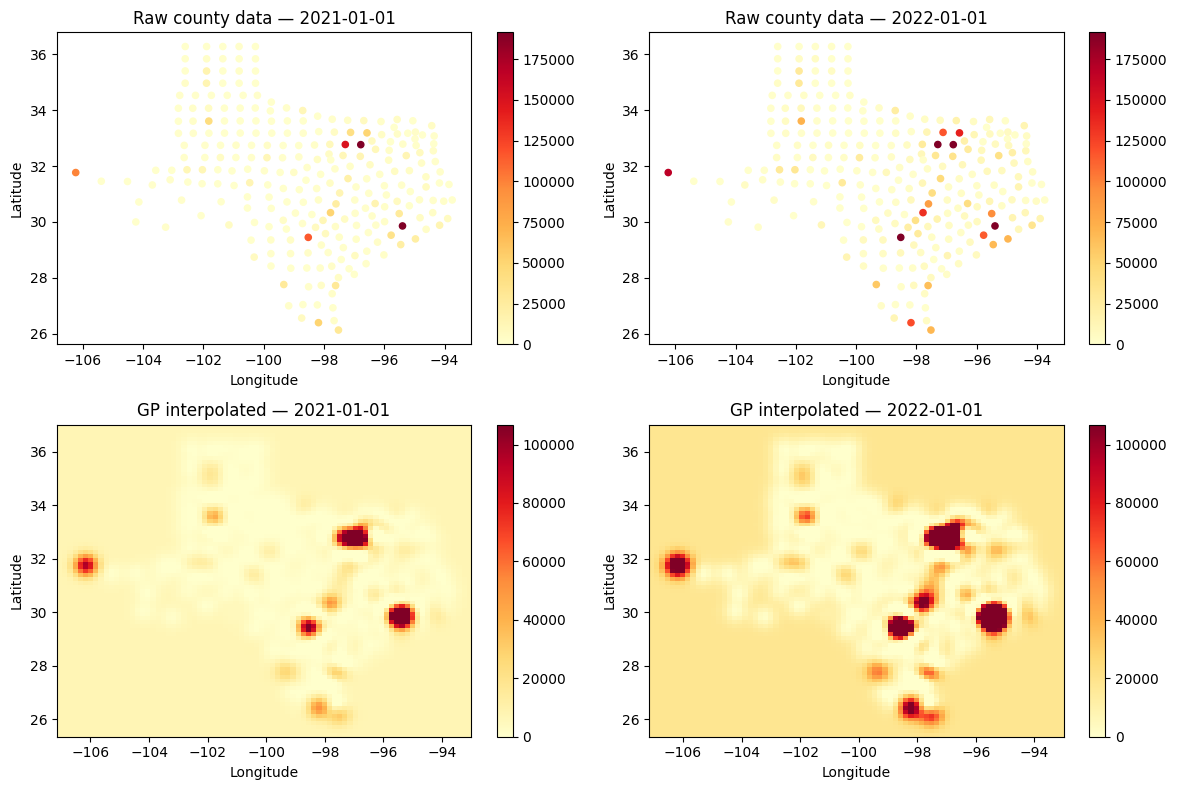

In [7]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

def build_grid(lon_min, lon_max, lat_min, lat_max, nx, ny):
    lons = np.linspace(lon_min, lon_max, nx)
    lats = np.linspace(lat_min, lat_max, ny)
    Lon, Lat = np.meshgrid(lons, lats, indexing="xy")
    return Lon, Lat

NX, NY = 80, 80
BBOX_PADDING_DEG = 0.5   

lon_min, lat_min, lon_max, lat_max = region_count.total_bounds
lon_min -= BBOX_PADDING_DEG;  lon_max += BBOX_PADDING_DEG
lat_min -= BBOX_PADDING_DEG;  lat_max += BBOX_PADDING_DEG

Lon, Lat = build_grid(lon_min, lon_max, lat_min, lat_max, NX, NY)
print(f"Bounding box: lon [{lon_min:.2f}, {lon_max:.2f}], lat [{lat_min:.2f}, {lat_max:.2f}]")
print(f"Grid shape  : {Lon.shape}")

cum_raw = {}
county_pts = {}

for day in all_days:
    df_day = region_nyt[region_nyt["date"] == day][["fips", "cases"]].copy()
    tmp = region_count[["GEOID", "clon", "clat"]].merge(df_day, left_on="GEOID", right_on="fips", how="left")
    tmp["cases"] = tmp["cases"].fillna(0.0)

    lon_pts = tmp["clon"].to_numpy(float)
    lat_pts = tmp["clat"].to_numpy(float)
    val     = tmp["cases"].to_numpy(float)

    X = np.c_[lon_pts, lat_pts]

    kernel = RBF(length_scale=0.5, length_scale_bounds=(0.1, 5.0))

    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, alpha=1e-3)
    gp.fit(X, val)

    grid_pred = gp.predict(np.c_[Lon.ravel(), Lat.ravel()]).reshape(Lon.shape)
    grid_cum = np.maximum(grid_pred, 0)
  
    ds = day.strftime("%Y-%m-%d")
    cum_raw[ds]    = grid_cum
    county_pts[ds] = (lon_pts, lat_pts, val)

plot_dates = ["2021-01-01", "2022-01-01"]

raw_vals = np.concatenate([county_pts[ds][2] for ds in plot_dates])
grid_vals = np.concatenate([cum_raw[ds].ravel() for ds in plot_dates])


vmax_raw = np.percentile(raw_vals, 99)
vmax_grid = np.percentile(grid_vals, 99)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for j, ds in enumerate(plot_dates):
    x, y, v = county_pts[ds]
    sc = ax[0, j].scatter(x, y, c=v, cmap="YlOrRd", s=20, vmin=0, vmax=vmax_raw)
    ax[0, j].set_title(f"Raw county data — {ds}")
    ax[0, j].set_xlabel("Longitude")
    ax[0, j].set_ylabel("Latitude")
    fig.colorbar(sc, ax=ax[0, j])

    im = ax[1, j].imshow(cum_raw[ds], origin="lower",
                         extent=[lon_min, lon_max, lat_min, lat_max],
                         cmap="YlOrRd", aspect="auto", vmin=0, vmax=vmax_grid)
    
    ax[1, j].set_title(f"GP interpolated — {ds}")
    ax[1, j].set_xlabel("Longitude")
    ax[1, j].set_ylabel("Latitude")
    fig.colorbar(im, ax=ax[1, j])

plt.tight_layout()
plt.show()

  Date          Raw cumulative max  Normalize cumulative max
  --------------------------------------------------------------------
  2020-07-01              30989.59               0.03
  2021-09-01             478354.69               0.48
  2022-01-01             623280.18               0.63
  2022-05-13             988556.25               1.00


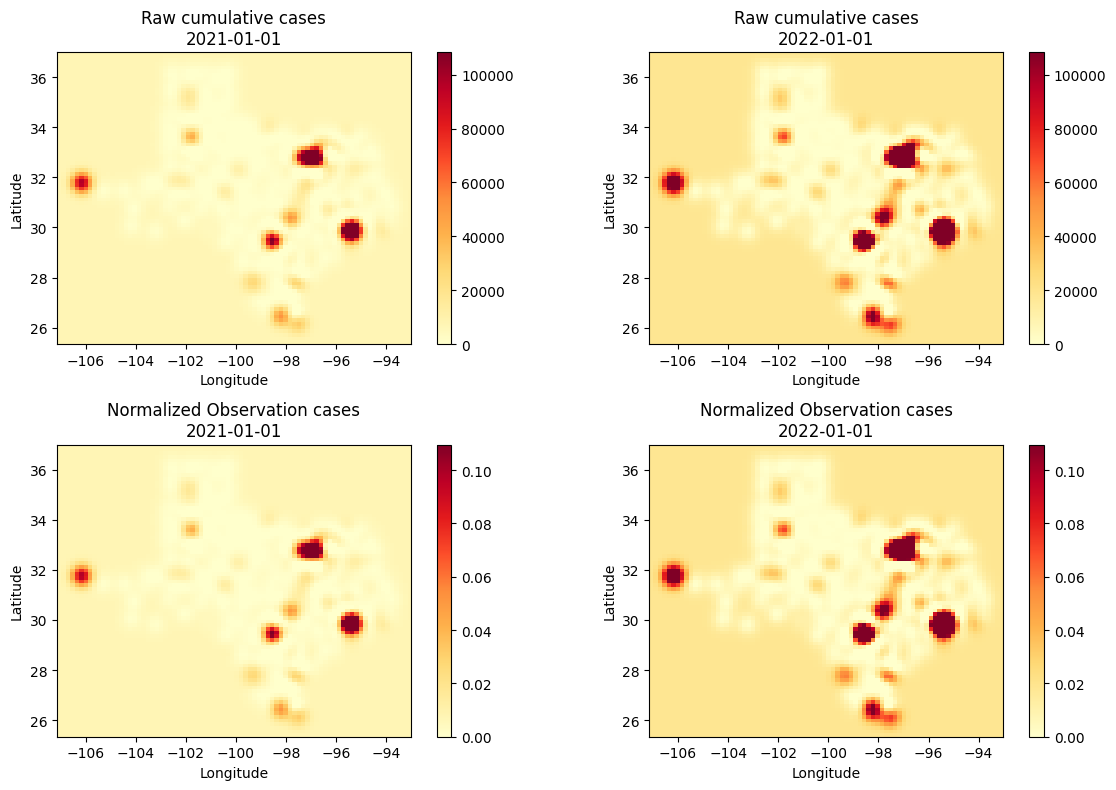

In [8]:
cum_raw = cum_raw
gmax = max(cum_raw[ds].max() for ds in cum_raw)
obs_norm = {ds: cum_raw[ds] / gmax for ds in cum_raw}

print(f"  {'Date':<12}  {'Raw cumulative max':>18}  {'Normalize cumulative max':>16}")
print(f"  {'-'*68}")
for ds in DATES:
    raw_max   = cum_raw[ds].max()
    norm_max  = obs_norm[ds].max()
    print(f"  {ds:<12}  {raw_max:>18.2f}  {norm_max:>17.2f}")

# --------- plot two dates ----------
plot_dates = ["2021-01-01", "2022-01-01"]
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

vmax_raw = np.percentile(
    np.concatenate([cum_raw[ds].ravel() for ds in cum_raw]),
    99
)

vmax_norm = np.percentile(
    np.concatenate([obs_norm[ds].ravel() for ds in obs_norm]),
    99
)

for j, ds in enumerate(plot_dates):
    im0 = ax[0, j].imshow(cum_raw[ds], origin="lower",
                          extent=[lon_min, lon_max, lat_min, lat_max], cmap="YlOrRd", vmin=0, vmax=vmax_raw)
    ax[0, j].set_title(f"Raw cumulative cases\n{ds}")
    ax[0, j].set_xlabel("Longitude"); ax[0, j].set_ylabel("Latitude")
    plt.colorbar(im0, ax=ax[0, j])

    im1 = ax[1, j].imshow(obs_norm[ds], origin="lower",
                          extent=[lon_min, lon_max, lat_min, lat_max], cmap="YlOrRd", vmin=0, vmax=vmax_norm)
    ax[1, j].set_title(f"Normalized Observation cases\n{ds}")
    ax[1, j].set_xlabel("Longitude"); ax[1, j].set_ylabel("Latitude")
    plt.colorbar(im1, ax=ax[1, j])

plt.tight_layout()
plt.show()

## THOMAS Algorithm (Tridiagonal Solver)

In [9]:
def LU_Thomas(a, b, c, r):
    n = len(r)
    w = np.zeros(n, float)  # solution
    l = np.zeros(n, float)  # lower factor
    u = np.zeros(n, float)  # upper factor
    z = np.zeros(n, float)  # intermediate

    # Forward sweep (LU decomposition)
    u[0] = b[0]
    for k in range(1, n):
        l[k] = a[k] / u[k-1]
        u[k] = b[k] - l[k] * c[k-1]

    # Forward substitution (solve L*z = r)
    z[0] = r[0]
    for k in range(1, n):
        z[k] = r[k] - l[k] * z[k-1]

    # Backward substitution (solve U*w = z)
    w[n-1] = z[n-1] / u[n-1]
    for k in range(n-2, -1, -1):
        w[k] = (z[k] - c[k] * w[k+1]) / u[k]

    return w

## ADI Sweep Function

In [10]:
def ADI_sweep(U, coeff, lx, ly, axis, dt):
    U = np.asarray(U, float)
    coeff = np.asarray(coeff, float)
    ny, nx = U.shape
    Uout = np.zeros_like(U)

    if axis == "x":  
        for j in range(ny):
            a = np.zeros(nx); b = np.zeros(nx)
            c = np.zeros(nx); r = np.zeros(nx)

            for i in range(nx):         
                a[i] = -lx if i > 0    else 0.0
                c[i] = -lx if i < nx-1 else 0.0
                b[i] = 1.0 + 2.0*lx + 0.25*dt*coeff[j, i]

                ym = U[j-1, i] if j > 0    else U[1,    i]  # reflect at bottom
                yp = U[j+1, i] if j < ny-1 else U[ny-2, i]  # reflect at top

                # r[i] = (1.0 - 2.0*lx - 0.25*dt*coeff[j, i]) * U[j, i] + ly*(ym + yp)
                r[i] = (1.0 - 2.0*ly - 0.25*dt*coeff[j, i]) * U[j, i] + ly*(ym + yp)

            Uout[j, :] = LU_Thomas(a, b, c, r)

    elif axis == "y":
        for i in range(nx):
            a = np.zeros(ny); b = np.zeros(ny)
            c = np.zeros(ny); r = np.zeros(ny)

            for j in range(ny):
                a[j] = -ly if j > 0    else 0.0
                c[j] = -ly if j < ny-1 else 0.0
                b[j] = 1.0 + 2.0*ly + 0.25*dt*coeff[j, i]

                xm = U[j, i-1] if i > 0    else U[j, 1]     # reflect at left
                xp = U[j, i+1] if i < nx-1 else U[j, nx-2]  # reflect at right

                # r[j] = (1.0 - 2.0*ly - 0.25*dt*coeff[j, i]) * U[j, i] + lx*(xm + xp)
                r[j] = (1.0 - 2.0*lx - 0.25*dt*coeff[j, i]) * U[j, i] + lx*(xm + xp)

            Uout[:, i] = LU_Thomas(a, b, c, r)

    else:
        raise ValueError("axis must be 'x' or 'y'")

    return Uout

# FORWARD SIR MODEL WITH NUDGING

In [28]:
dt = 0.5
steps = 2

# lam = 0.1
# dS  = 0.0005
# dI  = 0.0001
# kS  = 0.01 
# kI  = 0.01
# N = 1.0

# lam = 0.25
# dS  = 0.0005
# dI  = 0.0001
# kS  = 0.008 
# kI  = 0.008
# N = 1.0

lam = 0.25
dS  = 0.0005
dI  = 0.0001
kS  = 0.01 
kI  = 0.008
N = 1.0


USE_NUDGING = False
eta = 0.0   
EPS= 1e-8 

print("Running forward ADI SIR model with nudging...")
print(f"   Parameters: kS={kS}, kI={kI}, dS={dS}, dI={dI}, eta={eta}")
print(f"   Time steps: {steps} steps/day × {len(all_days)-1} days = {steps*(len(all_days)-1)} total steps")

# Grid spacing
hx = (lon_max - lon_min) / (NX - 1)
hy = (lat_max - lat_min) / (NY - 1)

# Diffusion weights
lxS = (dS * dt) / (2.0 * hx*hx) 
lyS = (dS * dt) / (2.0 * hy*hy) 
lxI = (dI * dt) / (2.0 * hx*hx) 
lyI = (dI * dt) / (2.0 * hy*hy) 

print(f"\nGrid spacing : hx={hx:.4f}°, hy={hy:.4f}°")
print(f"Diffusion weights: lxS={lxS:.4f}, lyS={lyS:.4f}, lxI={lxI:.4f}, lyI={lyI:.4f}")

# --- Initialize S and I on day 0 ---
start = min(DATES)
I0 = obs_norm[start]
I = 0.1 * I0
S = np.clip(N - I, 0.0, N) 

print(f"\n   Initial state on {start}:")
print(f"   I: min={I.min():.4f}, max={I.max():.4f}, mean={I.mean():.4f}")
print(f"   S: min={S.min():.4f}, max={S.max():.4f}, mean={S.mean():.4f}")

pred_I_raw = {start: I.copy()}
# pred_I_norm = {start: I.copy()}
daily_stats = []  

# --- Main time loop ---
print(f"\nSimulating day by day...")
for day_idx, day in enumerate(all_days[1:]):
    ds = day.strftime("%Y-%m-%d")

    for _ in range(steps):

        # I equation: I_t = -k_I*(lam - S)*I + dI*ΔI 
        coeff_I = kI*(lam - S)
        Istar = ADI_sweep(I, coeff_I, lxI, lyI, axis="x", dt=dt)
        Inew  = ADI_sweep(Istar, coeff_I, lxI, lyI, axis="y", dt=dt)
        I     = np.maximum(Inew, 0.0)

        # S equation: S_t = - k_S*I*S + dS*ΔS 
        coeff_S = kS*I
        Sstar = ADI_sweep(S, coeff_S, lxS, lyS, axis="x", dt=dt)
        Snew  = ADI_sweep(Sstar, coeff_S, lxS, lyS, axis="y", dt=dt)
        S     = np.maximum(Snew, 0.0)

        total = S + I
        mask  = total > N
        if np.any(mask):
            scale = N / (total[mask] + EPS)
            S[mask] *= scale
            I[mask] *= scale

        if USE_NUDGING and eta > 0:
            
            I_obs = obs_norm[ds]
            I     = (1.0 - eta) * I + eta * I_obs   
            I     = np.maximum(I, 0.0)
            S = np.clip(S, 0.0, N)
            
            total = S + I
            mask  = total > N
            if np.any(mask):
                scale = N / (total[mask] + EPS)
                S[mask] *= scale
                I[mask] *= scale

    daily_stats.append({
        "date"   : ds,
        "I_mean" : float(I.mean()),
        "S_mean" : float(S.mean()),
        "SI_mean": float((S + I).mean()) 
    })
    
    if ds in set(DATES):
        pred_I_raw[ds] = I.copy()
        print(f"Date: {ds} | I mean={I.mean():.4f}, max={I.max():.4f}")
        
    gmax_model = max(pred_I_raw[d].max() for d in pred_I_raw)
    pred_I_norm = {d: pred_I_raw[d] / (gmax_model + EPS) for d in pred_I_raw}

Running forward ADI SIR model with nudging...
   Parameters: kS=0.01, kI=0.008, dS=0.0005, dI=0.0001, eta=0.0
   Time steps: 2 steps/day × 681 days = 1362 total steps

Grid spacing : hx=0.1790°, hy=0.1476°
Diffusion weights: lxS=0.0039, lyS=0.0057, lxI=0.0008, lyI=0.0011

   Initial state on 2020-07-01:
   I: min=0.0000, max=0.0031, mean=0.0001
   S: min=0.9969, max=1.0000, mean=0.9999

Simulating day by day...
Date: 2021-09-01 | I mean=0.0008, max=0.0180
Date: 2022-01-01 | I mean=0.0016, max=0.0314
Date: 2022-05-13 | I mean=0.0033, max=0.0575


## VALIDATION & PLOTS

In [16]:
# print("Validation summary (normalized OBS vs MODEL I):")
# print(f"\n  {'Date':<12}  {'RMSE':>8}  {'Correlation':>12}")
# print(f"  {'-'*40}")

# for ds in DATES[1:]:
#     r = rmse(pred_I_norm[ds], obs_norm[ds])
#     c = corr(pred_I_norm[ds], obs_norm[ds])
#     print(f"  {ds:<12}  {r:>8.4f}  {c:>12.4f}")


# # --- Heatmaps: OBS proxy vs MODEL I ---
# plot_dates_str = DATES[1:]
# ncols = len(plot_dates_str)
# fig, axes = plt.subplots(2, ncols, figsize=(4*ncols, 7))

# for j, ds in enumerate(plot_dates_str):
#     im = axes[0, j].imshow(obs_norm[ds], origin="lower",
#                             extent=[lon_min, lon_max, lat_min, lat_max],
#                            cmap="YlOrRd", vmin=0, vmax=1)
#     axes[0, j].set_title(f"OBS proxy\n{ds}", fontsize=9)
#     axes[0, j].set_xlabel("lon"); axes[0, j].set_ylabel("lat")
#     plt.colorbar(im, ax=axes[0, j])

# for j, ds in enumerate(plot_dates_str):
#     im = axes[1, j].imshow(pred_I_norm[ds], origin="lower",
#                             extent=[lon_min, lon_max, lat_min, lat_max],
#                            cmap="YlOrRd", vmin=0, vmax=1)
#     axes[1, j].set_title(f"MODEL I\n{ds}", fontsize=9)
#     axes[1, j].set_xlabel("lon"); axes[1, j].set_ylabel("lat")
#     plt.colorbar(im, ax=axes[1, j])

# axes[0, 0].set_ylabel("OBS proxy\nlat", fontsize=9)
# axes[1, 0].set_ylabel("MODEL I\nlat",   fontsize=9)
# plt.suptitle("OBS proxy (top) vs MODEL I (bottom)", 
#              fontsize=12, y=1.01)
# plt.tight_layout()
# plt.show()

# # --- Scatter plots: one per date ---
# fig, axes = plt.subplots(1, ncols, figsize=(4*ncols, 4))
# for j, ds in enumerate(plot_dates_str):
#     a = obs_norm[ds].ravel()
#     b = pred_I_norm[ds].ravel()
#     r = rmse(pred_I_norm[ds], obs_norm[ds])
#     c = corr(pred_I_norm[ds], obs_norm[ds])
#     axes[j].scatter(a, b, s=4, alpha=0.3, color="steelblue")
#     axes[j].plot([0,1],[0,1], "r--", linewidth=1, label="perfect fit")
#     axes[j].set_title(f"{ds}\nCorr={c:.3f}, RMSE={r:.3f}", fontsize=9)
#     axes[j].set_xlabel("OBS proxy"); axes[j].set_ylabel("MODEL I")
#     axes[j].legend(fontsize=7); axes[j].grid(True, alpha=0.3)

# plt.suptitle("Scatter: OBS vs MODEL (normalized)", 
#              fontsize=12, y=1.02)
# plt.tight_layout()
# plt.show()

Validation summary (normalized OBS vs MODEL I):

  Date              RMSE   Correlation
  ----------------------------------------
  2020-07-01      0.0012        1.0000
  2021-09-01      0.0127        0.8947
  2022-01-01      0.0219        0.8616
  2022-05-13      0.0555        0.8146


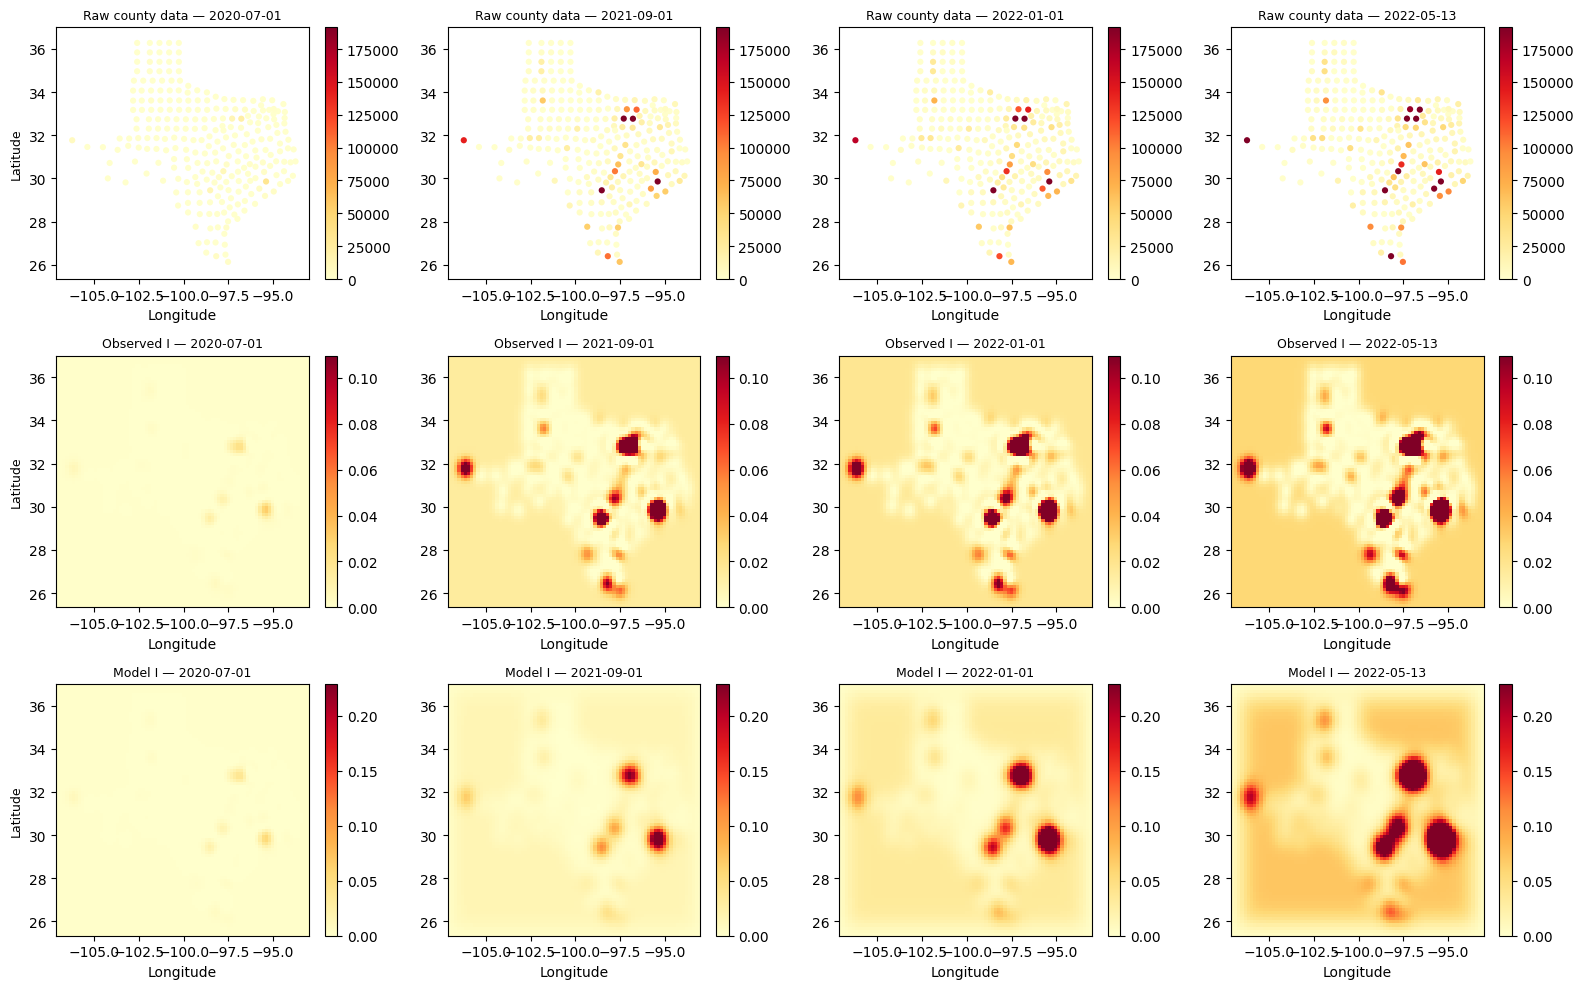

In [29]:
print("Validation summary (normalized OBS vs MODEL I):")
print(f"\n  {'Date':<12}  {'RMSE':>8}  {'Correlation':>12}")
print(f"  {'-'*40}")

for ds in DATES:
    r = rmse(pred_I_norm[ds], obs_norm[ds])
    c = corr(pred_I_norm[ds], obs_norm[ds])
    print(f"  {ds:<12}  {r:>8.4f}  {c:>12.4f}")

plot_dates_str = DATES
ncols = len(plot_dates_str)

fig, ax = plt.subplots(3, ncols, figsize=(4 * ncols, 10), squeeze=False)

vmax_raw = np.percentile(raw_vals, 99)
vmax_obs = np.percentile(
    np.concatenate([obs_norm[d].ravel() for d in obs_norm]),
    99
)
vmax_pred = np.percentile(
    np.concatenate([pred_I_norm[d].ravel() for d in pred_I_norm]),
    99
)

extent = [lon_min, lon_max, lat_min, lat_max]

# ── Row 0: raw county scatter ────────────────────────────────────────────────
for j, ds in enumerate(plot_dates_str):
    x, y, v = county_pts[ds]
    sc = ax[0, j].scatter(
        x, y, c=v, cmap="YlOrRd", s=20,
        vmin=0, vmax=vmax_raw, edgecolors="none"
    )
    ax[0, j].set_xlim(lon_min, lon_max)
    ax[0, j].set_ylim(lat_min, lat_max)
    ax[0, j].set_title(f"Raw county data — {ds}", fontsize=9)
    ax[0, j].set_xlabel("Longitude")
    fig.colorbar(sc, ax=ax[0, j])

# ── Row 1: OBS proxy imshow ──────────────────────────────────────────────────
for j, ds in enumerate(plot_dates_str):
    im = ax[1, j].imshow(
        obs_norm[ds], origin="lower", extent=extent,
        aspect="auto", cmap="YlOrRd", vmin=0, vmax=vmax_obs
    )
    ax[1, j].set_title(f"Observed I — {ds}", fontsize=9)
    ax[1, j].set_xlabel("Longitude")
    fig.colorbar(im, ax=ax[1, j])

# ── Row 2: MODEL I imshow ────────────────────────────────────────────────────
for j, ds in enumerate(plot_dates_str):
    im = ax[2, j].imshow(
        pred_I_norm[ds], origin="lower", extent=extent,
        aspect="auto", cmap="YlOrRd", vmin=0, vmax=vmax_pred
    )
    ax[2, j].set_title(f"Model I — {ds}", fontsize=9)
    ax[2, j].set_xlabel("Longitude")
    fig.colorbar(im, ax=ax[2, j])

# ── Row y-labels ─────────────────────────────────────────────────────────────
ax[0, 0].set_ylabel("Latitude", fontsize=9)
ax[1, 0].set_ylabel("Latitude", fontsize=9)
ax[2, 0].set_ylabel("Latitude", fontsize=9)

plt.tight_layout()

# Save the plot
plt.savefig("validation_obs_vs_modelI.png", dpi=300, bbox_inches="tight")

plt.show()

In [17]:
import numpy as np

all_x = []
all_y = []

for ds in county_pts:
    x, y, _ = county_pts[ds]
    all_x.append(x)
    all_y.append(y)

x_county = np.concatenate(all_x)
y_county = np.concatenate(all_y)

In [18]:
from scipy.spatial import ConvexHull
from matplotlib.path import Path

pts = np.column_stack((x_county, y_county))

hull = ConvexHull(pts)
hull_pts = pts[hull.vertices]

path = Path(hull_pts)

grid_pts = np.column_stack((Lon.ravel(), Lat.ravel()))
mask_flat = path.contains_points(grid_pts)

texas_mask = mask_flat.reshape(Lon.shape)

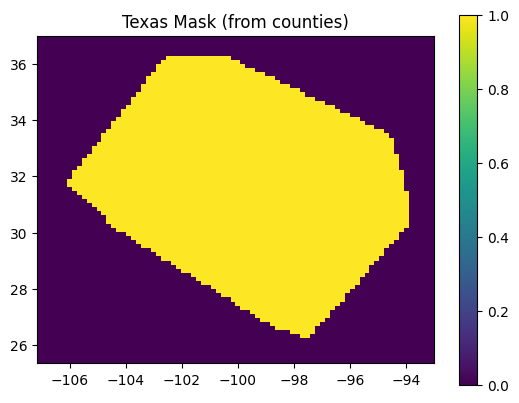

In [19]:
import matplotlib.pyplot as plt

plt.imshow(texas_mask, origin="lower", extent=extent)
plt.title("Texas Mask (from counties)")
plt.colorbar()
plt.show()

Validation summary (normalized OBS vs MODEL I):

  Date              RMSE   Correlation
  ----------------------------------------
  2020-07-01      0.0038        1.0000
  2021-09-01      0.0480        0.5130
  2022-01-01      0.1117        0.4196
  2022-05-13      0.2369        0.3126


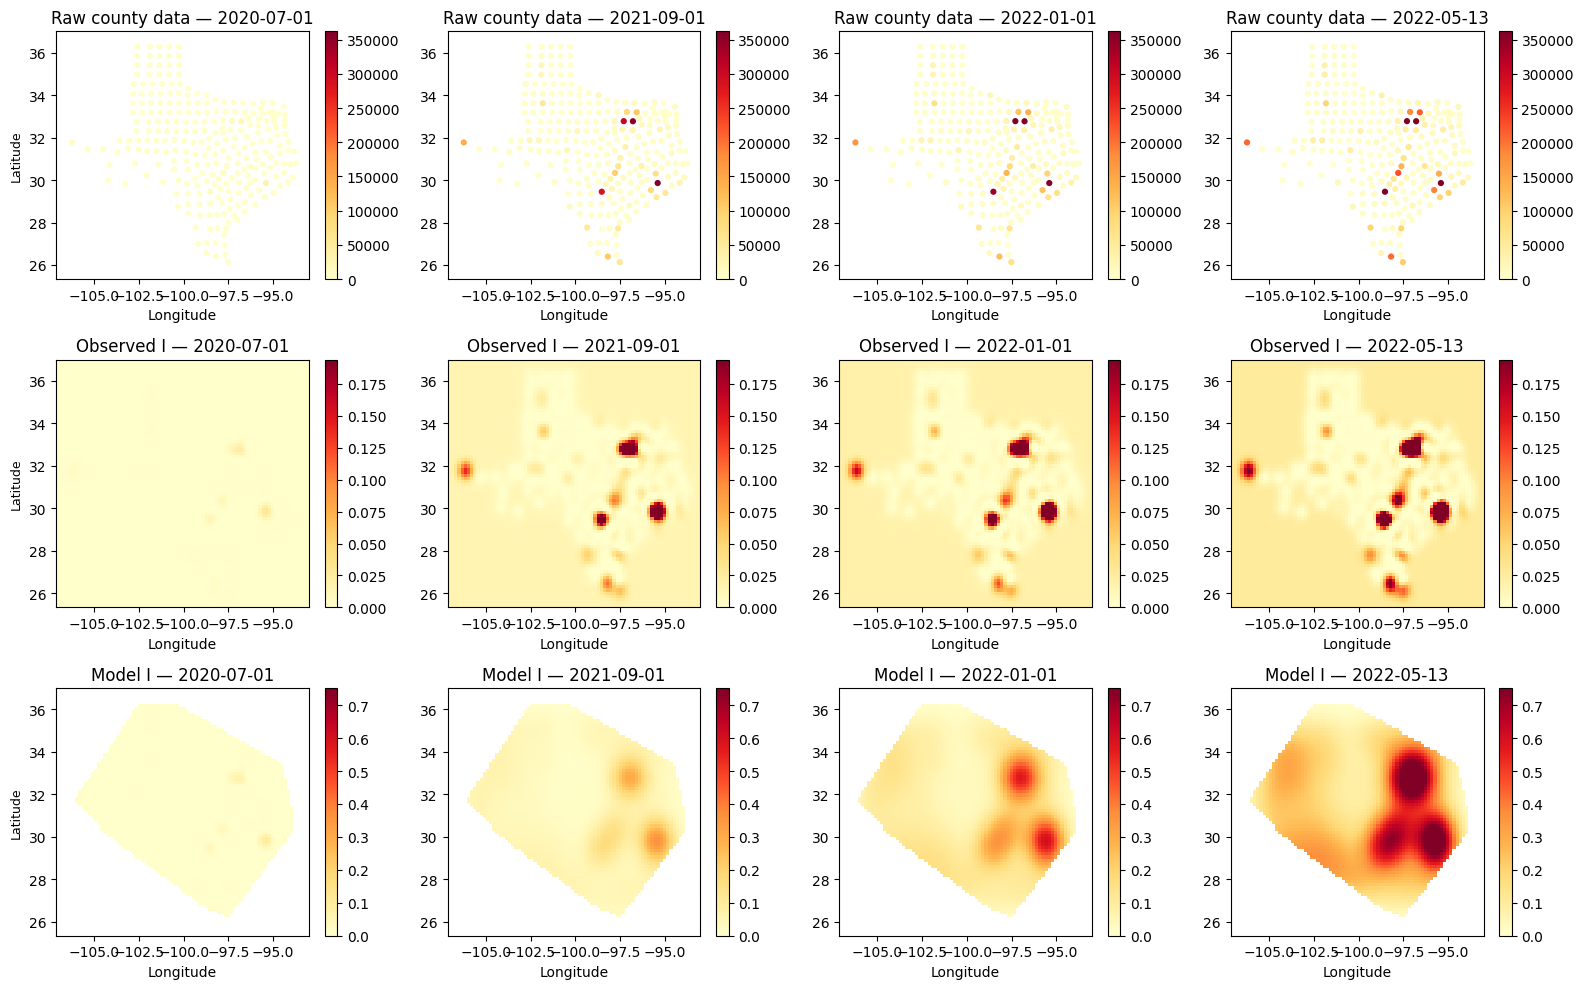

In [20]:
print("Validation summary (normalized OBS vs MODEL I):")
print(f"\n  {'Date':<12}  {'RMSE':>8}  {'Correlation':>12}")
print(f"  {'-'*40}")

for ds in DATES:
    r = rmse(pred_I_norm[ds], obs_norm[ds])
    c = corr(pred_I_norm[ds], obs_norm[ds])
    print(f"  {ds:<12}  {r:>8.4f}  {c:>12.4f}")

plot_dates_str = DATES
ncols = len(plot_dates_str)

fig, ax = plt.subplots(3, ncols, figsize=(4 * ncols, 10), squeeze=False)

vmax_raw = np.percentile(raw_vals, 99.5)
vmax_obs = np.percentile(
    np.concatenate([obs_norm[d].ravel() for d in obs_norm]),
    99.5
)
vmax_pred = np.percentile(
    np.concatenate([pred_I_norm[d].ravel() for d in pred_I_norm]),
    99.5
)

extent = [lon_min, lon_max, lat_min, lat_max]

# ── Row 0: raw county scatter ────────────────────────────────────────────────
for j, ds in enumerate(plot_dates_str):
    x, y, v = county_pts[ds]
    sc = ax[0, j].scatter(
        x, y, c=v, cmap="YlOrRd", s=20,
        vmin=0, vmax=vmax_raw, edgecolors="none"
    )
    ax[0, j].set_xlim(lon_min, lon_max)
    ax[0, j].set_ylim(lat_min, lat_max)
    ax[0, j].set_title(f"Raw county data — {ds}", fontsize=12)
    ax[0, j].set_xlabel("Longitude")
    fig.colorbar(sc, ax=ax[0, j])

# ── Row 1: OBS masked imshow ─────────────────────────────────────────────────
for j, ds in enumerate(plot_dates_str):
    obs_masked = np.where(texas_mask, obs_norm[ds], np.nan)
    im = ax[1, j].imshow(
        obs_norm[ds], origin="lower", extent=extent,
        aspect="auto", cmap="YlOrRd", vmin=0, vmax=vmax_obs
    )
    ax[1, j].set_title(f"Observed I — {ds}", fontsize=12)
    ax[1, j].set_xlabel("Longitude")
    fig.colorbar(im, ax=ax[1, j])

# ── Row 2: MODEL I masked imshow ─────────────────────────────────────────────
for j, ds in enumerate(plot_dates_str):
    model_masked = np.where(texas_mask, pred_I_norm[ds], np.nan)
    im = ax[2, j].imshow(
        model_masked, origin="lower", extent=extent,
        aspect="auto", cmap="YlOrRd", vmin=0, vmax=vmax_pred
    )
    ax[2, j].set_title(f"Model I — {ds}", fontsize=12)
    ax[2, j].set_xlabel("Longitude")
    fig.colorbar(im, ax=ax[2, j])

# ── Row y-labels ─────────────────────────────────────────────────────────────
ax[0, 0].set_ylabel("Latitude", fontsize=9)
ax[1, 0].set_ylabel("Latitude", fontsize=9)
ax[2, 0].set_ylabel("Latitude", fontsize=9)

plt.tight_layout()
plt.savefig("validation_obs_vs_modelI.png", dpi=300, bbox_inches="tight")
plt.show()